<h1 align = 'center'> Hamza Salah </h1>
<h2 align = 'center'> DSC 680: Applied Data Science </h2>
<h2 align = 'center'> Project 2: Retail IRI Detection</h2>

In [1]:
# Import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

In [2]:
# Load dataset
df = pd.read_csv('retail_data.csv', parse_dates=['Date'],
    date_format='%Y-%m-%d')

In [3]:
df.head(1)

,Date,Store_ID,Product_ID,Inventory_level_t,Inventory_level_t_minus_1,In_stock_t,Stock_adjustment_t,Items_sold_t,PO_received_qty_t,Physical_Count_t,IRI_Detected_tomorrow
0,2021-01-01,Store_01,Product_001,64,217.784524,1,0,34,0,64,0


In [4]:
# add time based features
df['Day_of_Week'] = df['Date'].dt.dayofweek # 0=Monday, 6=Sunday

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460000 entries, 0 to 1459999
Data columns (total 12 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Date                       1460000 non-null  datetime64[ns]
 1   Store_ID                   1460000 non-null  object        
 2   Product_ID                 1460000 non-null  object        
 3   Inventory_level_t          1460000 non-null  int64         
 4   Inventory_level_t_minus_1  1460000 non-null  float64       
 5   In_stock_t                 1460000 non-null  int64         
 6   Stock_adjustment_t         1460000 non-null  int64         
 7   Items_sold_t               1460000 non-null  int64         
 8   PO_received_qty_t          1460000 non-null  int64         
 9   Physical_Count_t           1460000 non-null  int64         
 10  IRI_Detected_tomorrow      1460000 non-null  int64         
 11  Day_of_Week                1460000 no

In [6]:
df.columns.tolist()

['Date',
 'Store_ID',
 'Product_ID',
 'Inventory_level_t',
 'Inventory_level_t_minus_1',
 'In_stock_t',
 'Stock_adjustment_t',
 'Items_sold_t',
 'PO_received_qty_t',
 'Physical_Count_t',
 'IRI_Detected_tomorrow',
 'Day_of_Week']

In [7]:
df.describe()

,Date,Inventory_level_t,Inventory_level_t_minus_1,In_stock_t,Stock_adjustment_t,Items_sold_t,PO_received_qty_t,Physical_Count_t,IRI_Detected_tomorrow,Day_of_Week
count,1460000,1.460000e+06,1.460000e+06,1.460000e+06,1.460000e+06,1.460000e+06,1.460000e+06,1.460000e+06,1.460000e+06,1.460000e+06
mean,2022-12-31 11:59:59.999999744,2.177196e+02,2.176567e+02,5.486548e-01,2.662329e-03,1.902288e+01,7.915834e+00,2.195170e+02,3.716582e-01,3.002055e+00
min,2021-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,-5.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2021-12-31 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01,0.000000e+00,4.000000e+00,0.000000e+00,1.000000e+00
50%,2022-12-31 12:00:00,1.700000e+01,1.700000e+01,1.000000e+00,0.000000e+00,1.700000e+01,0.000000e+00,1.700000e+01,0.000000e+00,3.000000e+00
75%,2023-12-31 06:00:00,1.480000e+02,1.490000e+02,1.000000e+00,0.000000e+00,2.600000e+01,0.000000e+00,1.480000e+02,1.000000e+00,5.000000e+00
max,2024-12-30 00:00:00,6.498000e+03,6.498000e+03,1.000000e+00,5.000000e+01,8.300000e+01,1.490000e+02,6.498000e+03,1.000000e+00,6.000000e+00
std,NaN,5.366709e+02,5.362091e+02,4.976273e-01,1.233631e+01,1.114166e+01,2.812351e+01,5.359490e+02,4.832479e-01,2.001198e+00


--- Target Variable Distribution ---
IRI_Detected_tomorrow
0    0.628342
1    0.371658
Name: proportion, dtype: float64


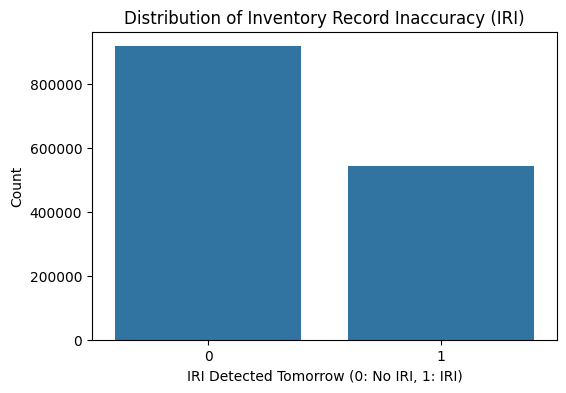


--- Summary Statistics for Key Features ---
       Inventory_level_t  Items_sold_t  Stock_adjustment_t  PO_received_qty_t
count       1.460000e+06  1.460000e+06        1.460000e+06       1.460000e+06
mean        2.177196e+02  1.902288e+01        2.662329e-03       7.915834e+00
std         5.366709e+02  1.114166e+01        1.233631e+01       2.812351e+01
min         0.000000e+00  0.000000e+00       -5.000000e+01       0.000000e+00
25%         0.000000e+00  1.000000e+01        0.000000e+00       0.000000e+00
50%         1.700000e+01  1.700000e+01        0.000000e+00       0.000000e+00
75%         1.480000e+02  2.600000e+01        0.000000e+00       0.000000e+00
max         6.498000e+03  8.300000e+01        5.000000e+01       1.490000e+02


In [8]:
# 1. Check the distribution of the target variable (IRI)
print("--- Target Variable Distribution ---")
print(df['IRI_Detected_tomorrow'].value_counts(normalize=True))

# 2. Visualize the imbalance
# This will show the massive difference between '0' (Accurate) and '1' (IRI)

plt.figure(figsize=(6, 4))
sns.countplot(x='IRI_Detected_tomorrow', data=df)
plt.title('Distribution of Inventory Record Inaccuracy (IRI)')
plt.xlabel('IRI Detected Tomorrow (0: No IRI, 1: IRI)')
plt.ylabel('Count')
plt.show()

print("\n--- Summary Statistics for Key Features ---")
print(df[['Inventory_level_t', 'Items_sold_t', 'Stock_adjustment_t', 'PO_received_qty_t']].describe())

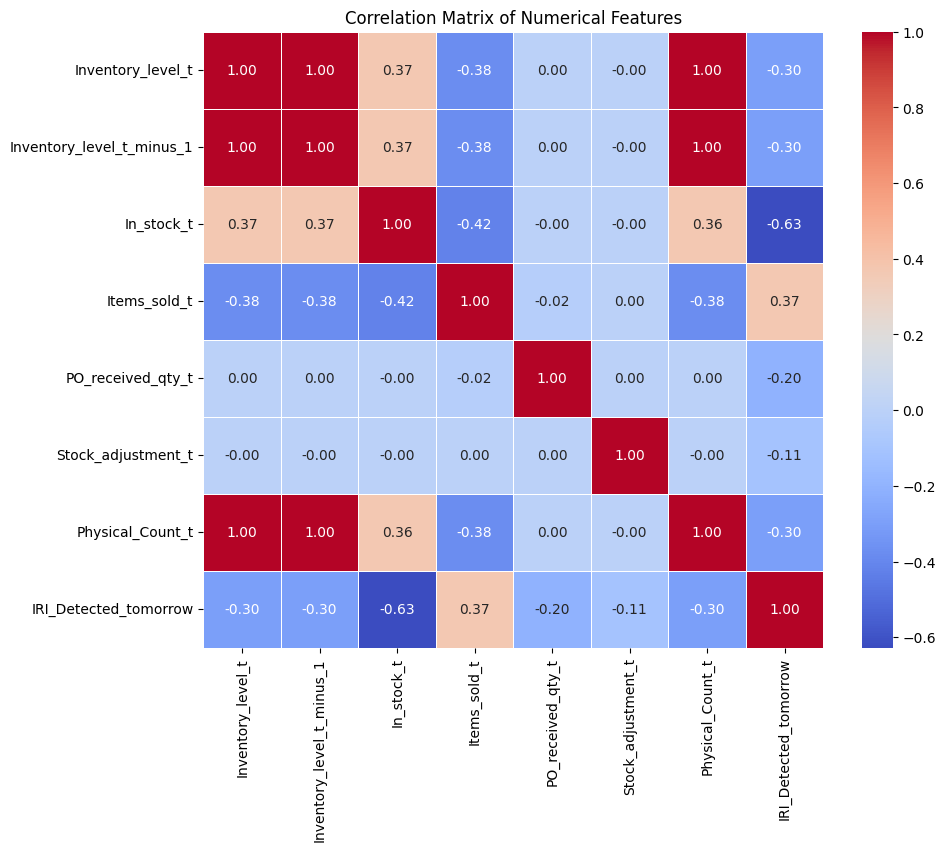


--- Feature Correlation with IRI_Detected_tomorrow ---
IRI_Detected_tomorrow        1.000000
Items_sold_t                 0.367921
Stock_adjustment_t          -0.110769
PO_received_qty_t           -0.203336
Inventory_level_t_minus_1   -0.299008
Physical_Count_t            -0.301041
Inventory_level_t           -0.303153
In_stock_t                  -0.627404
Name: IRI_Detected_tomorrow, dtype: float64


In [9]:
# Select only the numerical features and the target variable
numerical_features = ['Inventory_level_t', 'Inventory_level_t_minus_1', 
                      'In_stock_t', 'Items_sold_t', 'PO_received_qty_t', 
                      'Stock_adjustment_t', 'Physical_Count_t', 
                      'IRI_Detected_tomorrow']

correlation_matrix = df[numerical_features].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f",
            linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Extract correlations with the target variable for discussion
print("\n--- Feature Correlation with IRI_Detected_tomorrow ---")
print(correlation_matrix['IRI_Detected_tomorrow'].sort_values(ascending=False))

C:\Users\Hamza\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


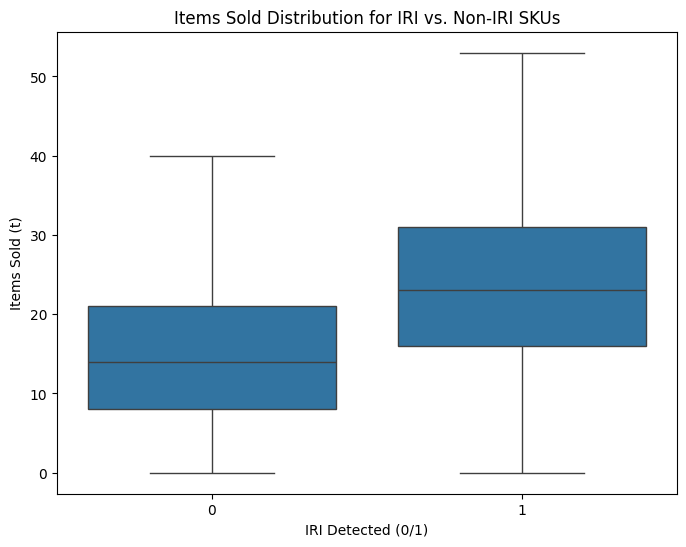

In [10]:
# Create box plots for the most relevant continuous variables vs. the target

# Focus on Item Sales vs. IRI
plt.figure(figsize=(8, 6))
sns.boxplot(x='IRI_Detected_tomorrow', y='Items_sold_t', data=df, showfliers=False) # showfliers=False removes extreme outliers for a cleaner view
plt.title('Items Sold Distribution for IRI vs. Non-IRI SKUs')
plt.xlabel('IRI Detected (0/1)')
plt.ylabel('Items Sold (t)')
plt.show()

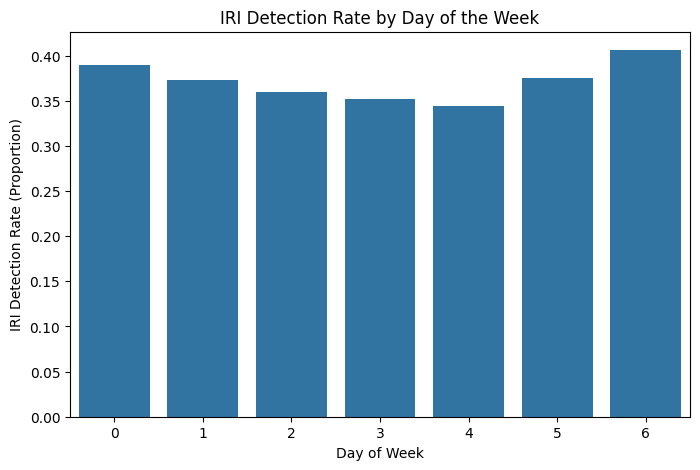

In [11]:
# Calculate the IRI rate for each day of the week
day_iri_rate = df.groupby('Day_of_Week')['IRI_Detected_tomorrow'].mean().reset_index()

# Visualize the IRI rate by Day of the Week
plt.figure(figsize=(8, 5))
sns.barplot(x='Day_of_Week', y='IRI_Detected_tomorrow', data=day_iri_rate)
plt.title('IRI Detection Rate by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('IRI Detection Rate (Proportion)')
plt.show()

### Group By Stats & Charts

In [12]:
by_store = df.groupby(by = 'Store_ID')
by_store['Inventory_level_t'].sum()

Store_ID
Store_01    36461040
Store_02    22475037
Store_03    34091179
Store_04    34296867
Store_05    21435492
Store_06    46260836
Store_07    24511864
Store_08    24313389
Store_09    25627665
Store_10    48397259
Name: Inventory_level_t, dtype: int64

### Train-Test Split

In [13]:
training_df = df[df['Date'] < '2024-01-01']
testing_df =  df[df['Date'] >= '2024-01-01'].reset_index(drop = True)

### One Hot Encoding

In [14]:
# identify catergory columns
cat_columns = training_df.select_dtypes('object').columns.to_list()
cat_columns

['Store_ID', 'Product_ID']

In [15]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_val_encoded  = encoder.fit_transform(training_df[cat_columns])
test_encoded = encoder.transform(testing_df[cat_columns])

train_val_ohe = pd.DataFrame(train_val_encoded, columns = encoder.get_feature_names_out(cat_columns), index = training_df.index)
test_ohe = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_columns), index=testing_df.index)

train_val_df = pd.concat([training_df, train_val_ohe], axis=1).drop(columns=cat_columns)
test_df = pd.concat([testing_df, test_ohe], axis=1).drop(columns=cat_columns)

### X-Y Split

In [16]:
x_train = train_val_df.drop(columns = ['IRI_Detected_tomorrow', 'Date'])
y_train = train_val_df['IRI_Detected_tomorrow']

x_test = test_df.drop(columns = ['IRI_Detected_tomorrow', 'Date'])
y_test = test_df['IRI_Detected_tomorrow']

### Training

In [17]:
model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [18]:
y_proba = model.predict_proba(x_test)[:, 1]
new_threshold = 0.50
y_pred = np.where(y_proba >= new_threshold, 1, 0) 

### Evaluation

In [19]:
accuracy_score(y_test, y_pred)

0.8675616438356164

In [20]:
# cofusion matrix
cm =  confusion_matrix(y_test,y_pred)
print(cm)

[[198784  30547]
 [ 17793 117876]]


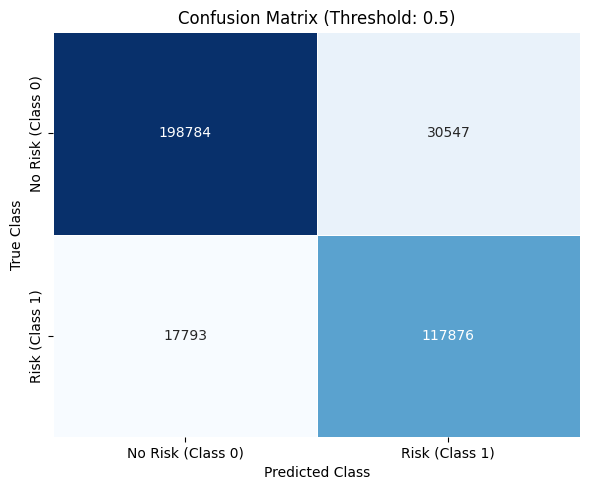

In [21]:
# Confusion Matrix Visualization ---
target_names = ['No Risk (Class 0)', 'Risk (Class 1)']
df_cm = pd.DataFrame(cm, index=target_names, columns=target_names)
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=None, cmap='Blues', linewidths=.5)
plt.title(f'Confusion Matrix (Threshold: {new_threshold})')
plt.ylabel('True Class')
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

Model demonstrates strong and balanced performance with an 81.09%, correctly identifying 83.16% of actual inventory issues (Recall). The key challenge is the trade-off between the 23,507 false alarms that waste audit time and the 18,065 missed issues that negatively impact inventory integrity.

In [22]:
# classification report
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.87      0.89    229331
           1       0.79      0.87      0.83    135669

    accuracy                           0.87    365000
   macro avg       0.86      0.87      0.86    365000
weighted avg       0.87      0.87      0.87    365000



In [23]:
# ROC Curve and AUC Calculation
fpr, tpr, thresholds = roc_curve(y_test, y_proba) 
roc_auc = auc(fpr, tpr)
print(f"\nROC AUC: {roc_auc:.4f}")


ROC AUC: 0.9143


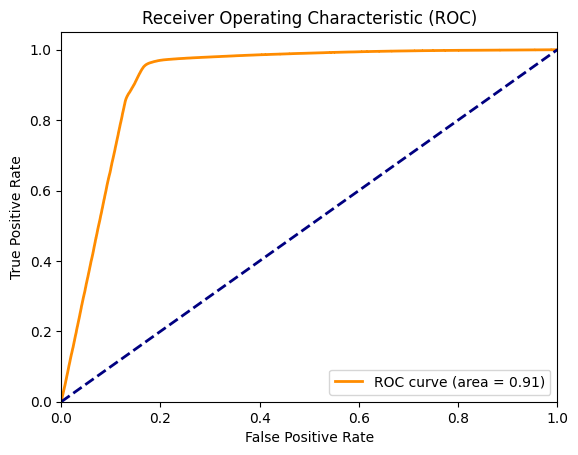

In [24]:
# --- 6. ROC Curve Visualization ---
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Results Comparison

In [25]:
results = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_proba,
    "y_pred": y_pred
})

df_results = pd.DataFrame(results, columns = ('y_true', 'y_prob', 'y_pred'))

In [26]:
inverse_labels = encoder.inverse_transform(test_ohe)

In [27]:
df_test_ids = pd.DataFrame(inverse_labels, columns = ('Store_ID', 'Product_ID'))

df_results = df_results.join(df_test_ids)

df_results = df_results.join(test_df['Date'])

df_results = df_results[['Date', 'Store_ID', 'Product_ID', 'y_prob', 'y_pred', 'y_true']]

In [28]:
df_results.head(1)


,Date,Store_ID,Product_ID,y_prob,y_pred,y_true
0,2024-01-01,Store_01,Product_001,0.938616,1,1


### Generate Top 10 IRI Suspect List by Store and Date Function

In [29]:
def print_suspect_list(df, store_id_input, date_input):
    """
    Filters the DataFrame for a specific store and date, formats the output title,
    and returns the top 10 suspects based on a 'y_prob' column.
    """
    
    # 1. Input Validation and Padding
    try:
        # Ensure store_id_input is treated as an integer for padding
        store_num = int(store_id_input)
    except ValueError:
        print(f"Error: Store ID input '{store_id_input}' must be a number.")
        return pd.DataFrame() 
    
    # Pad to 2 digits. Example: 2 becomes '02'
    padded_store_num = f'{store_num:02d}' 
    
    # Reconstruct the full Store_ID string
    target_store_id = f'Store_{padded_store_num}'
    
    date_obj = pd.to_datetime(date_input)

    # Prepare readable date components
    month_name = date_obj.strftime('%B')
    day_number = date_obj.day
    year_number = date_obj.year
    
    # 3. Filter the DataFrame (using the input DataFrame 'df')
    suspect_df = df[
        (df['Store_ID'] == target_store_id) & 
        (df['Date'].dt.date == date_obj.date())
    ].copy()
    
    # 4. Print Title and Handle Empty Result
    if suspect_df.empty:
        print(f"No records found for Store: {target_store_id} on Date: {date_input}")
    else:
        # Use the original, unpadded store_num for a cleaner print title
        print(f"High-Risk IRI Suspect List for Store {store_num}, {month_name} {day_number}, {year_number}") 
        
    # 5. Sort and Limit Results
    # Check if 'y_prob' exists before sorting
    if 'y_prob' in suspect_df.columns:
        suspect_df = suspect_df.sort_values(by='y_prob', ascending=False).head(10).reset_index(drop=True)
    else:
        print("Warning: 'y_prob' column not found for sorting. Returning unfiltered results.")

    suspect_df = suspect_df.drop(columns = ['Date', 'Store_ID', 'y_prob', 'y_pred'])

    suspect_df = suspect_df.rename(columns = {'Product_ID' : 'Suspect Products','y_true' : 'Audit Result (1=Actual IRI)'})

    return suspect_df

In [30]:
df[(df['Date']== '2024-7-10') & (df['Store_ID'] == 'Store_10') & (df['Product_ID'] == 'Product_017')]

,Date,Store_ID,Product_ID,Inventory_level_t,Inventory_level_t_minus_1,In_stock_t,Stock_adjustment_t,Items_sold_t,PO_received_qty_t,Physical_Count_t,IRI_Detected_tomorrow,Day_of_Week
1338646,2024-07-10,Store_10,Product_017,0,0.0,0,0,6,0,3,1,2


In [31]:
audit_list1 = print_suspect_list(df_results, 1, '2024-1-1')
audit_list1

High-Risk IRI Suspect List for Store 1, January 1, 2024


,Suspect Products,Audit Result (1=Actual IRI)
0,Product_067,0
1,Product_001,1
2,Product_075,1
3,Product_006,1
4,Product_047,1
5,Product_012,1
6,Product_008,1
7,Product_022,1
8,Product_031,1
9,Product_045,1


In [32]:
audit_list2 = print_suspect_list(df_results, 6, '2024-12-30')
audit_list2

High-Risk IRI Suspect List for Store 6, December 30, 2024


,Suspect Products,Audit Result (1=Actual IRI)
0,Product_061,0
1,Product_049,0
2,Product_070,0
3,Product_089,1
4,Product_057,0
5,Product_094,1
6,Product_033,1
7,Product_075,1
8,Product_037,1
9,Product_041,1
